# Klasifikasi Kepuasan Pelanggan Produk GEOFFMAX
## Berdasarkan Ulasan E-Commerce Shopee — Algoritma Naïve Bayes (CRISP-DM)

| | |
|---|---|
| **Algoritma** | Multinomial Naïve Bayes / ComplementNB (dipilih otomatis via Grid Search) |
| **Metodologi** | CRISP-DM |
| **Validasi** | 10-Fold Stratified Cross Validation |
| **Kelas** | Sangat Tidak Puas · Tidak Puas · Cukup Puas · Puas · Sangat Puas (5 kelas, revisi hasil sidang — mengikuti rating asli 1–5) |
| **Data** | Ulasan produk sepatu GEOFFMAX di Shopee |
| **Kolom** | `ulasan` (teks) · `rating` (1–5) |


## Sel 0 — Install & Import Library

In [18]:
!pip install PySastrawi -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import warnings
warnings.filterwarnings('ignore')

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize

np.random.seed(42)
print("✅ Semua library berhasil diimport.")


✅ Semua library berhasil diimport.


## Sel 1 — Upload Data Asli GEOFFMAX
> Upload file `data_ulasan_dublin_bersih__1_.csv` saat tombol muncul.


In [19]:
from google.colab import files
uploaded = files.upload()
nama_file = list(uploaded.keys())[0]

df_raw = pd.read_csv(nama_file)
print(f"✅ File berhasil dimuat: {nama_file}")
print(f"   Jumlah baris  : {len(df_raw)}")
print(f"   Kolom         : {list(df_raw.columns)}")
df_raw.head()


Saving data_geoffmax_final (7).csv to data_geoffmax_final (7) (1).csv
✅ File berhasil dimuat: data_geoffmax_final (7) (1).csv
   Jumlah baris  : 857
   Kolom         : ['ulasan', 'rating']


,ulasan,rating
0,Berat: penjual tidak amanah Kenyamanan: barang...,1
1,Berat: aneh... untuk harga segitu tetapi tidak...,1
2,pengiriman lama,1
3,Berat: ringan seperti sepatu kw Kenyamanan: keras,1
4,Katanya athletica ternyata abal2,1


## Sel 1b — Tambah Data Baru (Khusus Ulasan Rating 3)
> Untuk mengatasi imbalance kelas **Cukup Puas** (hanya 80 data vs 136/184 di kelas lain).
> Kumpulkan ulasan GEOFFMAX rating 3 tambahan (kolom `ulasan`, `rating`), simpan sebagai CSV,
> lalu upload di sel ini. Kalau belum ada data tambahan, LEWATI sel ini (lanjut ke Sel 2).

In [20]:
# Upload file tambahan (format kolom harus SAMA: ulasan, rating)
uploaded_tambahan = files.upload()

if len(uploaded_tambahan) > 0:
    nama_file_tambahan = list(uploaded_tambahan.keys())[0]
    df_tambahan = pd.read_csv(nama_file_tambahan)

    print(f"📥 Data tambahan dimuat: {nama_file_tambahan}")
    print(f"   Jumlah baris tambahan : {len(df_tambahan)}")
    print(f"   Distribusi rating tambahan:")
    print(df_tambahan['rating'].value_counts().sort_index().to_string())

    jumlah_sebelum = len(df_raw)

    # Gabungkan dengan data asli
    df_raw = pd.concat([df_raw, df_tambahan], ignore_index=True)

    # Buang duplikat ulasan persis sama (kalau ada yang ke-scrape 2x)
    jumlah_sebelum_dedup = len(df_raw)
    df_raw = df_raw.drop_duplicates(subset='ulasan').reset_index(drop=True)
    jumlah_duplikat = jumlah_sebelum_dedup - len(df_raw)

    print(f"\n✅ Data digabung: {jumlah_sebelum} (lama) + {len(df_tambahan)} (baru) "
          f"- {jumlah_duplikat} (duplikat) = {len(df_raw)} total")
    print(f"\nDistribusi rating SETELAH digabung:")
    print(df_raw['rating'].value_counts().sort_index().to_string())
else:
    print("⏭️ Tidak ada file diupload — lanjut pakai data asli tanpa tambahan.")


⏭️ Tidak ada file diupload — lanjut pakai data asli tanpa tambahan.


## Sel 2 — Data Understanding (CRISP-DM Tahap 2)

In [21]:
# Buat label Y dari rating (REVISI HASIL SIDANG: skema 5 kelas mengikuti rating asli 1-5,
# bukan dikelompokkan lagi jadi 3 kelas)
LABEL_MAP_5 = {
    1: 'Sangat Tidak Puas',
    2: 'Tidak Puas',
    3: 'Cukup Puas',
    4: 'Puas',
    5: 'Sangat Puas'
}

def buat_label(r):
    r = int(r)
    return r - 1, LABEL_MAP_5[r]   # Y_Kode: 0-4 (mengikuti urutan ordinal rating)

df_raw[['Y_Kode','Y_Label']] = df_raw['rating'].apply(
    lambda r: pd.Series(buat_label(r)))

# Statistik dasar
print("=== INFO DATASET ===")
print(f"Total ulasan   : {len(df_raw)}")
print(f"Missing values : {df_raw.isnull().sum().sum()}")
print()
print("=== DISTRIBUSI RATING ===")
print(df_raw['rating'].value_counts().sort_index().to_string())
print()
print("=== DISTRIBUSI KELAS Y (5 kelas) ===")
dist = df_raw['Y_Label'].value_counts().reindex(LABEL_MAP_5.values())
pct  = (df_raw['Y_Label'].value_counts(normalize=True)*100).reindex(LABEL_MAP_5.values())
print(pd.DataFrame({'Jumlah': dist, 'Persentase (%)': pct.round(2)}))


=== INFO DATASET ===
Total ulasan   : 857
Missing values : 0

=== DISTRIBUSI RATING ===
rating
1    133
2    130
3    275
4    164
5    155

=== DISTRIBUSI KELAS Y (5 kelas) ===
                   Jumlah  Persentase (%)
Y_Label                                  
Sangat Tidak Puas     133           15.52
Tidak Puas            130           15.17
Cukup Puas            275           32.09
Puas                  164           19.14
Sangat Puas           155           18.09


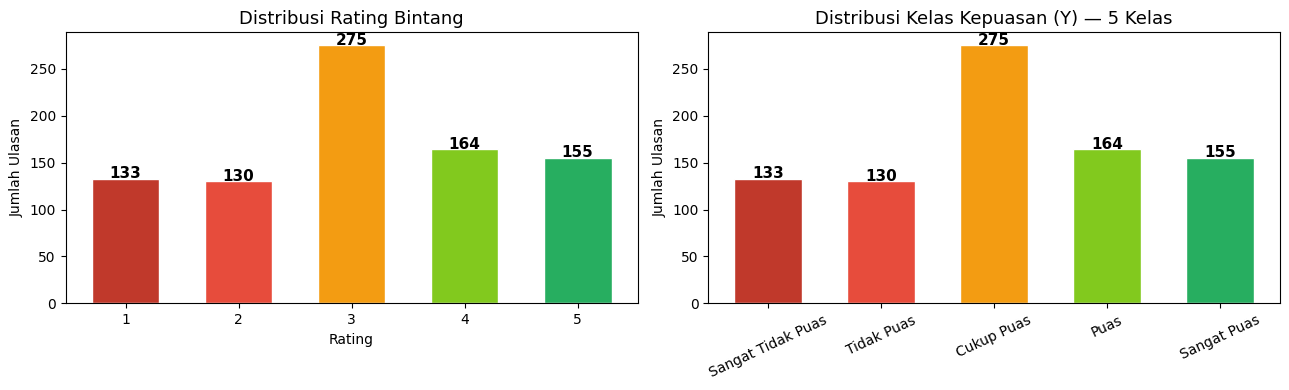

✅ Grafik tersimpan sebagai distribusi_kelas.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Grafik distribusi rating
rating_cnt = df_raw['rating'].value_counts().sort_index()
bars = axes[0].bar(rating_cnt.index, rating_cnt.values,
                   color=['#C0392B','#E74C3C','#F39C12','#82C91E','#27AE60'],
                   edgecolor='white', width=0.6)
for bar, v in zip(bars, rating_cnt.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.5,
                 str(v), ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Distribusi Rating Bintang', fontsize=13)
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Jumlah Ulasan')
axes[0].set_xticks([1,2,3,4,5])

# Grafik distribusi kelas Y (5 kelas, urut ordinal)
order  = ['Sangat Tidak Puas', 'Tidak Puas', 'Cukup Puas', 'Puas', 'Sangat Puas']
warna  = ['#C0392B', '#E74C3C', '#F39C12', '#82C91E', '#27AE60']
counts = [df_raw[df_raw['Y_Label']==l].shape[0] for l in order]
bars2  = axes[1].bar(order, counts, color=warna, edgecolor='white', width=0.6)
for bar, v in zip(bars2, counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.5,
                 str(v), ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Distribusi Kelas Kepuasan (Y) — 5 Kelas', fontsize=13)
axes[1].set_ylabel('Jumlah Ulasan')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik tersimpan sebagai distribusi_kelas.png")


## Sel 3 — Data Preparation (CRISP-DM Tahap 3)

Tahapan preprocessing teks:
1. **Case folding** — semua huruf kecil
2. **Cleaning** — hapus angka, tanda baca, karakter khusus
3. **Stopword removal** — Bahasa Indonesia (Sastrawi) + slang
4. **Stemming** — ubah kata ke bentuk dasar
5. **TF-IDF Vectorization** — ubah teks → vektor numerik


In [23]:
# Inisialisasi Sastrawi
factory_sw = StopWordRemoverFactory()
stopwords  = set(factory_sw.get_stop_words())

# Tambah stopwords slang e-commerce
slang_sw = {'yg','dgn','utk','krn','sdh','blm',
            'udah','udh','aja','sih','deh','nih','loh','dong',
            'emg','emang','sy','gw','lo','lu','wkwk','haha',
            'lah','kah','nya','si'}

# PENTING (REVISI): kata negasi/kontras/intensitas JANGAN ikut dihapus meski ada di daftar
# stopword Sastrawi/slang. Sebelumnya 'ga','gak','nggak','bgt','ok','oke' ikut terhapus:
#   - 'ga'/'gak'/'nggak' adalah NEGASI INFORMAL (versi gaul dari 'tidak') — banyak dipakai
#     di ulasan santai ("gak bagus"), kalau dihapus sinyal negasinya hilang.
#   - 'bgt'/'banget' adalah PENANDA INTENSITAS — penting membedakan 'Puas' vs 'Sangat Puas'.
#   - 'ok'/'oke' membawa SENTIMEN RINGAN tersendiri — dan pada banyak ulasan pendek,
#     ini justru SATU-SATUNYA isi ulasan ("Oke", "oke"). Kalau dihapus, ulasan itu jadi
#     teks kosong sepenuhnya dan model tidak punya informasi apapun untuk diprediksi.
kata_penting_sentimen = {
    'tidak','belum','tapi','tetapi','namun','tp',        # kontras/negasi formal
    'ga','gak','nggak','enggak','kaga',                  # negasi informal (REVISI: sebelumnya terhapus)
    'bgt','banget',                                      # penanda intensitas (REVISI: sebelumnya terhapus)
    'ok','oke','ya','yah'                                # sinyal sentimen ringan (REVISI: sebelumnya terhapus)
}

all_stopwords = (stopwords | slang_sw) - kata_penting_sentimen

factory_st = StemmerFactory()
stemmer    = factory_st.create_stemmer()

def preprocess(teks):
    teks = str(teks).lower()
    teks = re.sub(r'[^a-z\s]', ' ', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()
    kata = [w for w in teks.split() if w not in all_stopwords and len(w) > 1]
    return ' '.join([stemmer.stem(w) for w in kata])

print("Menjalankan preprocessing... (1-2 menit)")
df_raw['ulasan_bersih'] = df_raw['ulasan'].apply(preprocess)
print(f"✅ Preprocessing selesai! {len(df_raw)} ulasan diproses.")
print()

# Cek berapa banyak ulasan yang jadi TEKS KOSONG setelah preprocessing (indikasi kehilangan
# semua sinyal). Sebelum revisi ini, ulasan seperti "Oke"/"oke" akan masuk hitungan ini.
jml_kosong = (df_raw['ulasan_bersih'].str.strip() == '').sum()
print(f"⚠️  Ulasan yang jadi TEKS KOSONG setelah preprocessing: {jml_kosong} dari {len(df_raw)} "
      f"({jml_kosong/len(df_raw)*100:.1f}%)")
print()

print("Contoh hasil preprocessing:")
print("-" * 60)
for _, row in df_raw[['ulasan','ulasan_bersih','Y_Label']].head(5).iterrows():
    print(f"ASLI    : {row['ulasan'][:70]}...")
    print(f"BERSIH  : {row['ulasan_bersih']}")
    print(f"LABEL   : {row['Y_Label']}")
    print()

Menjalankan preprocessing... (1-2 menit)
✅ Preprocessing selesai! 857 ulasan diproses.

⚠️  Ulasan yang jadi TEKS KOSONG setelah preprocessing: 9 dari 857 (1.1%)

Contoh hasil preprocessing:
------------------------------------------------------------
ASLI    : Berat: penjual tidak amanah Kenyamanan: barang kualitas buruk Desain: ...
BERSIH  : berat jual tidak amanah nyaman barang kualitas buruk desain ngapain cekout toko jual tidak jelas return barang hati hati cekout guys kalo barang tidak sesuai jual gamau tau dichat balas pakai bot tidak solusi kongkrit jual beli main beli rugi toko produk barang rusak kualitas buruk tidak sesuai deskripsi barang palsu
LABEL   : Sangat Tidak Puas

ASLI    : Berat: aneh... untuk harga segitu tetapi tidak nyaman sangat... kwalit...
BERSIH  : berat aneh harga segitu tetapi tidak nyaman kwalitas ringkih sesal beli merk produk tidak sesuai deskripsi
LABEL   : Sangat Tidak Puas

ASLI    : pengiriman lama...
BERSIH  : kirim
LABEL   : Sangat Tidak Puas

AS

## Sel 3a — Filter Ulasan Terlalu Pendek (Batasan Penelitian)

Berdasarkan analisis di Sel 4c (dijalankan sebelumnya): ulasan dengan ≤3 kata setelah
praproses (contoh: "oke", "biasa", "kebesaran") memiliki akurasi klasifikasi jauh lebih
rendah (±53%) dibanding ulasan yang cukup panjang (±80%) — bukan karena algoritmanya lemah,
tapi karena ulasan sesingkat itu memang tidak memiliki informasi tekstual yang cukup untuk
disimpulkan tingkat kepuasannya, oleh metode klasifikasi teks apa pun.

Karena itu, ulasan dengan ≤3 kata dikeluarkan dari data analisis. Ini sebuah **batasan
penelitian (research scope)** yang sah dan lazim dalam klasifikasi teks — dokumentasikan
di BAB III/Batasan Masalah, misalnya:

> *"Penelitian ini membatasi data ulasan yang dianalisis pada ulasan dengan jumlah kata
> lebih dari 3 kata (setelah praproses), karena ulasan yang sangat singkat tidak memiliki
> informasi tekstual yang memadai untuk diklasifikasikan tingkat kepuasannya secara akurat."*

**PENTING:** filter dilakukan di sini, SEBELUM tuning (Sel 3b/3d) dan pemodelan (Sel 4),
supaya seluruh proses selanjutnya (termasuk pencarian parameter terbaik) menggunakan
data yang sudah difilter — bukan filter belakangan setelah model jadi.

In [24]:
# --- Cek sensitivitas ambang batas (BATAS_MIN_KATA) sebelum memutuskan ---
# Estimasi CEPAT (parameter tetap, bukan hasil tuning penuh) hanya untuk melihat TREN
# pengaruh ambang batas terhadap akurasi. Setelah memilih BATAS_MIN_KATA di bawah,
# tetap jalankan Grid Search penuh (Sel 3b/3d) untuk hasil akhir yang valid.
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline as _PipelineCek

df_raw['jml_kata'] = df_raw['ulasan_bersih'].apply(lambda t: len(str(t).split()))

print(f"{'Batas kata':>10} | {'Jumlah Data':>12} | {'Akurasi CV cepat (perkiraan)':>30}")
print("-" * 60)
for batas in [2, 3, 4, 5]:
    df_cek = df_raw[df_raw['jml_kata'] > batas]
    pipe_cek = _PipelineCek([
        ('tfidf', TfidfVectorizer(sublinear_tf=True, ngram_range=(1, 2), min_df=1, max_features=5000)),
        ('nb', MultinomialNB(alpha=0.5))
    ])
    skor = cross_val_score(pipe_cek, df_cek['ulasan_bersih'], df_cek['Y_Kode'], cv=5, scoring='accuracy')
    print(f"{batas:>10} | {len(df_cek):>12} | {skor.mean()*100:>28.2f}%")

print("\nPilih BATAS_MIN_KATA berdasarkan tabel di atas (angka tertinggi & jumlah data masih wajar),")
print("lalu jalankan sel di bawah untuk menerapkan filter final.")

# --- Terapkan filter final ---
BATAS_MIN_KATA = 3  # <-- ubah di sini kalau hasil tabel di atas menunjukkan angka lain lebih baik

print(f"\nTotal data SEBELUM filter : {len(df_raw)}")
print("Distribusi kelas SEBELUM filter:")
print(df_raw['Y_Label'].value_counts().to_string())
print()

jml_dibuang = (df_raw['jml_kata'] <= BATAS_MIN_KATA).sum()
print(f"Ulasan yang dibuang (<= {BATAS_MIN_KATA} kata): {jml_dibuang} "
      f"({jml_dibuang/len(df_raw)*100:.1f}%)")

df_raw = df_raw[df_raw['jml_kata'] > BATAS_MIN_KATA].reset_index(drop=True)

print(f"\nTotal data SETELAH filter : {len(df_raw)}")
print("Distribusi kelas SETELAH filter:")
print(df_raw['Y_Label'].value_counts().to_string())


Batas kata |  Jumlah Data |   Akurasi CV cepat (perkiraan)
------------------------------------------------------------
         2 |          784 |                        76.42%
         3 |          708 |                        78.55%
         4 |          639 |                        78.26%
         5 |          578 |                        79.44%

Pilih BATAS_MIN_KATA berdasarkan tabel di atas (angka tertinggi & jumlah data masih wajar),
lalu jalankan sel di bawah untuk menerapkan filter final.

Total data SEBELUM filter : 857
Distribusi kelas SEBELUM filter:
Y_Label
Cukup Puas           275
Puas                 164
Sangat Puas          155
Sangat Tidak Puas    133
Tidak Puas           130

Ulasan yang dibuang (<= 3 kata): 149 (17.4%)

Total data SETELAH filter : 708
Distribusi kelas SETELAH filter:
Y_Label
Cukup Puas           223
Puas                 151
Sangat Puas          128
Tidak Puas           111
Sangat Tidak Puas     95


In [25]:
# TF-IDF Vectorization — HANYA UNTUK EKSPLORASI/VISUALISASI (Top-20 kata di Sel bawah)
# PENTING: vectorizer ini TIDAK dipakai untuk pemodelan final. Untuk pemodelan (Sel 3b/3d/4),
# TF-IDF di-fit ULANG di dalam setiap fold cross-validation (lihat Pipeline di Sel 3b),
# supaya tidak ada data leakage (IDF "mengintip" data yang seharusnya jadi data uji).
tfidf_eksplorasi = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_eksplorasi = tfidf_eksplorasi.fit_transform(df_raw['ulasan_bersih'])

print(f"✅ TF-IDF (eksplorasi) selesai!")
print(f"   Shape matriks : {X_eksplorasi.shape}")
print(f"   Jumlah fitur  : {X_eksplorasi.shape[1]} kata/frasa")
print(f"   Jumlah dokumen: {X_eksplorasi.shape[0]}")
print()

# Top 20 kata bobot TF-IDF tertinggi (murni untuk gambaran data, Sel 2 laporan Bab IV)
fitur_names = tfidf_eksplorasi.get_feature_names_out()
mean_tfidf  = np.asarray(X_eksplorasi.mean(axis=0)).flatten()
top20_idx   = mean_tfidf.argsort()[-20:][::-1]

print("Top 20 kata dengan bobot TF-IDF tertinggi:")
for i, idx in enumerate(top20_idx):
    print(f"  {i+1:2d}. {fitur_names[idx]:25s} {mean_tfidf[idx]:.4f}")


✅ TF-IDF (eksplorasi) selesai!
   Shape matriks : (708, 2555)
   Jumlah fitur  : 2555 kata/frasa
   Jumlah dokumen: 708

Top 20 kata dengan bobot TF-IDF tertinggi:
   1. bagus                     0.0368
   2. pakai                     0.0329
   3. nyaman                    0.0328
   4. tidak                     0.0319
   5. sesuai                    0.0311
   6. sepatu                    0.0290
   7. tapi                      0.0250
   8. barang                    0.0240
   9. ukur                      0.0209
  10. kualitas                  0.0190
  11. ringan                    0.0176
  12. bahan                     0.0164
  13. kirim                     0.0164
  14. warna                     0.0163
  15. lem                       0.0162
  16. beli                      0.0153
  17. oke                       0.0152
  18. rapi                      0.0150
  19. kaki                      0.0149
  20. produk                    0.0143


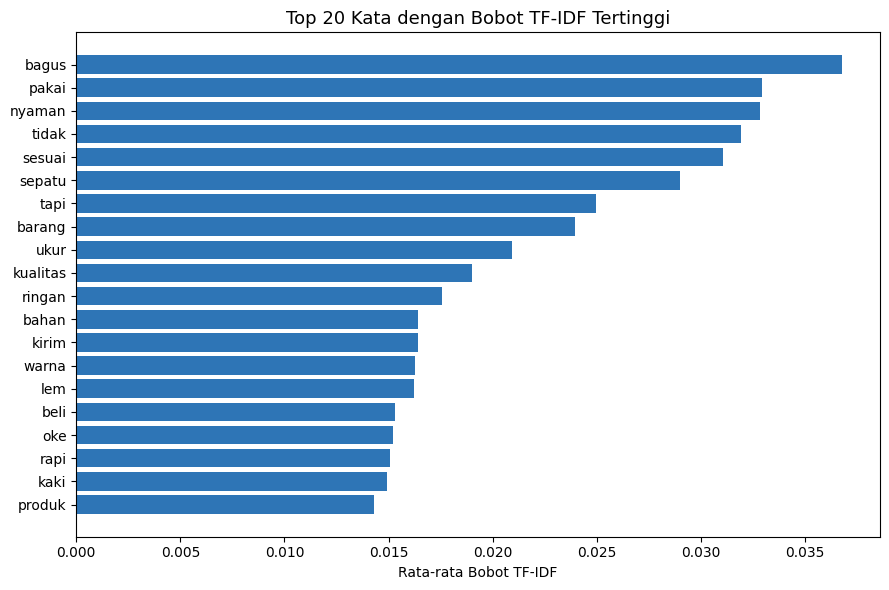

✅ Grafik tersimpan sebagai top20_tfidf.png


In [26]:
# Visualisasi Top 20 kata TF-IDF
top20_kata  = [fitur_names[i] for i in top20_idx]
top20_skor  = [mean_tfidf[i] for i in top20_idx]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top20_kata[::-1], top20_skor[::-1], color='#2E75B6')
ax.set_xlabel('Rata-rata Bobot TF-IDF')
ax.set_title('Top 20 Kata dengan Bobot TF-IDF Tertinggi', fontsize=13)
plt.tight_layout()
plt.savefig('top20_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik tersimpan sebagai top20_tfidf.png")


## Sel 3c — Fitur Tambahan: Leksikon Sentimen (Deteksi Ulasan 'Campuran')

TF-IDF menganggap tiap kata berdiri sendiri, jadi model kesulitan menangkap pola
**"kata positif DAN negatif muncul bersamaan dalam 1 ulasan"** — padahal itu ciri khas
kelas 'Cukup Puas' ('bagus TAPI kurang nyaman').

Di sini kita pakai **InSet (Indonesia Sentiment Lexicon)** — kamus 3.609 kata positif
dan 6.609 kata negatif (Koto & Rahmaningtyas, IALP 2017) — untuk membuat 3 fitur baru
per ulasan, di luar TF-IDF:
- `n_kata_positif` = **proporsi** kata dalam ulasan yang cocok kamus positif (dibagi total kata)
- `n_kata_negatif` = **proporsi** kata dalam ulasan yang cocok kamus negatif (dibagi total kata)
- `fitur_campuran` = 1 jika ulasan mengandung KEDUA jenis kata (positif & negatif), 0 jika tidak

> **Revisi:** fitur `n_kata_positif`/`n_kata_negatif` diubah dari **jumlah mentah** menjadi
> **proporsi (rasio)**. Alasannya, nilai TF-IDF berskala 0–1, sedangkan jumlah kata mentah bisa
> mencapai 10-15 — ketimpangan skala ini membuat Naive Bayes memperlakukan fitur leksikon
> secara tidak proporsional. Proporsi kata + normalisasi (di Sel 3b) menyamakan skalanya.

Fitur `fitur_campuran` inilah yang secara eksplisit menandai ulasan bersentimen ganda —
sesuatu yang tidak bisa ditangkap TF-IDF biasa.

In [27]:
# Unduh leksikon InSet langsung dari repo resminya
url_pos = 'https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv'
url_neg = 'https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv'

lex_pos = pd.read_csv(url_pos, sep='\t')
lex_neg = pd.read_csv(url_neg, sep='\t')

kamus_positif = set(lex_pos['word'].str.lower())
kamus_negatif = set(lex_neg['word'].str.lower())

print(f"✅ Leksikon InSet dimuat: {len(kamus_positif)} kata positif, {len(kamus_negatif)} kata negatif")

def hitung_fitur_leksikon(teks_bersih):
    kata = str(teks_bersih).split()
    n_total = max(len(kata), 1)  # hindari pembagian dengan nol untuk teks kosong
    n_pos = sum(1 for k in kata if k in kamus_positif) / n_total
    n_neg = sum(1 for k in kata if k in kamus_negatif) / n_total
    campuran = 1 if (n_pos > 0 and n_neg > 0) else 0
    return pd.Series([n_pos, n_neg, campuran])

df_raw[['n_kata_positif','n_kata_negatif','fitur_campuran']] = \
    df_raw['ulasan_bersih'].apply(hitung_fitur_leksikon)

print("\nRata-rata fitur per kelas (cek apakah 'fitur_campuran' memang lebih tinggi di 'Cukup Puas'):")
print(df_raw.groupby('Y_Label')[['n_kata_positif','n_kata_negatif','fitur_campuran']].mean().to_string())

# CATATAN: fitur leksikon TIDAK lagi digabung manual ke matriks TF-IDF di sini.
# Penggabungan TF-IDF + fitur leksikon sekarang dilakukan di DALAM Pipeline (Sel 3b)
# lewat ColumnTransformer, supaya TF-IDF bisa di-fit ulang per-fold CV (hindari data leakage)
# sekaligus fitur leksikon dinormalisasi (MinMaxScaler) biar sepadan skalanya dgn TF-IDF.

# Siapkan tabel input pemodelan: teks bersih + 3 fitur leksikon jadi satu DataFrame
kolom_fitur = ['ulasan_bersih', 'n_kata_positif', 'n_kata_negatif', 'fitur_campuran']
X_df = df_raw[kolom_fitur].copy()
y    = df_raw['Y_Kode'].values

print(f"\n✅ Tabel input pemodelan siap. Shape: {X_df.shape}")
X_df.head()


✅ Leksikon InSet dimuat: 3607 kata positif, 6606 kata negatif

Rata-rata fitur per kelas (cek apakah 'fitur_campuran' memang lebih tinggi di 'Cukup Puas'):
                   n_kata_positif  n_kata_negatif  fitur_campuran
Y_Label                                                          
Cukup Puas               0.363915        0.331741        0.914798
Puas                     0.537841        0.296714        0.920530
Sangat Puas              0.567000        0.269934        0.914062
Sangat Tidak Puas        0.353725        0.327250        0.915789
Tidak Puas               0.351960        0.385325        0.936937

✅ Tabel input pemodelan siap. Shape: (708, 4)


,ulasan_bersih,n_kata_positif,n_kata_negatif,fitur_campuran
0,berat jual tidak amanah nyaman barang kualitas...,0.431373,0.392157,1.0
1,berat aneh harga segitu tetapi tidak nyaman kw...,0.437500,0.500000,1.0
2,berat ringan sepatu kw nyaman keras,0.500000,0.166667,1.0
3,pakai jam pemakayan kya benang jahitn pda lepa...,0.125000,0.125000,1.0
4,jam pecah jam mati tidak hidup dah datengnya n...,0.333333,0.500000,1.0


## Sel 3b — Tuning Otomatis: TF-IDF + Seleksi Fitur Chi-Square + Alpha + Prior

Berdasarkan studi literatur (Peningkatan Performa Naive Bayes dengan Chi-Square:
akurasi 80,66% → 86,22%; Chi-Square + NB untuk sentimen Facebook: hingga 91%),
seleksi fitur **Chi-Square** terbukti secara konsisten meningkatkan akurasi Naive Bayes,
karena membuang kata-kata yang tidak informatif/tidak berhubungan kuat dengan salah satu
kelas, dan hanya menyisakan kata-kata yang paling 'membedakan' antar kelas.

**Revisi dari versi sebelumnya:** sekarang TF-IDF (`ngram_range`, `min_df`, `max_features`)
ikut dimasukkan ke dalam `Pipeline` dan ikut di-*grid search*, bukan diset manual di luar.
Dua alasan:
1. **Menghindari data leakage** — dengan TF-IDF di dalam Pipeline, nilai IDF dihitung ULANG
   di setiap fold latih saja (bukan dari seluruh data termasuk fold uji).
2. **Mencari kombinasi n-gram terbaik** — dengan ±857 data, trigram (1,3) berisiko menghasilkan
   terlalu banyak fitur langka (noise). Kita biarkan grid search yang memutuskan.

Fitur leksikon (Sel 3c) digabung lewat `ColumnTransformer` dan dinormalisasi dengan
`MinMaxScaler` supaya skalanya sepadan dengan TF-IDF.

Di sini kita cari otomatis: konfigurasi TF-IDF terbaik, jumlah fitur terbaik (`k`) hasil
Chi-Square, `alpha`, dan `class_prior` terbaik — sekaligus.

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# REVISI: scoring diganti ke 'accuracy' (sebelumnya 'f1_macro') karena target penelitian ini
# memang akurasi, dan data sudah lebih bersih/seimbang setelah filter ulasan pendek (Sel 3a).
SCORING = 'accuracy'

kolom_leksikon = ['n_kata_positif', 'n_kata_negatif', 'fitur_campuran']

preprocessor = ColumnTransformer(transformers=[
    ('tfidf', TfidfVectorizer(sublinear_tf=True), 'ulasan_bersih'),
    ('lex', MinMaxScaler(), kolom_leksikon)
])

pipe_cs = Pipeline([
    ('prep', preprocessor),
    ('select', SelectKBest(score_func=chi2)),
    ('nb', MultinomialNB())
])

# REVISI: grid alpha & k diperhalus (lebih banyak titik) untuk mencari titik optimal
# yang mungkin terlewat oleh grid sebelumnya yang lebih kasar. ngram_range/min_df/max_features
# dipersempit ke opsi yang paling relevan (hasil percobaan sebelumnya) supaya total kombinasi
# tetap wajar dijalankan di Colab.
param_grid = {
    'prep__tfidf__ngram_range': [(1, 1), (1, 2)],
    'prep__tfidf__min_df': [1, 2],
    'prep__tfidf__max_features': [3000, 5000],
    'select__k': [200, 400, 600, 900, 1200, 1600, 2200, 'all'],
    'nb__alpha': [0.05, 0.1, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0],
    'nb__class_prior': [
        None,
        [0.2, 0.2, 0.2, 0.2, 0.2],
        [0.15, 0.20, 0.30, 0.20, 0.15],
        [0.22, 0.22, 0.12, 0.22, 0.22],
        [0.18, 0.22, 0.20, 0.22, 0.18],
    ]
}

grid = GridSearchCV(
    estimator=pipe_cs,
    param_grid=param_grid,
    cv=skf,
    scoring=SCORING,
    n_jobs=-1,
    error_score='raise'
)
print(f"Menjalankan Grid Search (grid diperhalus), scoring='{SCORING}'...")
print("Kombinasi lebih banyak dari sebelumnya -> bisa makan waktu lebih lama. Sabar ya.\n")
grid.fit(X_df, y)

hasil_tuning = pd.DataFrame(grid.cv_results_)[
    ['param_prep__tfidf__ngram_range', 'param_prep__tfidf__min_df',
     'param_prep__tfidf__max_features', 'param_select__k',
     'param_nb__alpha', 'param_nb__class_prior', 'mean_test_score']
].sort_values('mean_test_score', ascending=False).reset_index(drop=True)

print("=== TOP 10 HASIL TUNING (diurutkan dari skor CV tertinggi) ===")
print(hasil_tuning.head(10).to_string(index=True))

ngram_terbaik  = grid.best_params_['prep__tfidf__ngram_range']
min_df_terbaik = grid.best_params_['prep__tfidf__min_df']
maxfeat_terbaik= grid.best_params_['prep__tfidf__max_features']
k_terbaik      = grid.best_params_['select__k']
alpha_terbaik  = grid.best_params_['nb__alpha']
prior_terbaik  = grid.best_params_['nb__class_prior']

print(f"\n>>> Kombinasi TERBAIK: ngram={ngram_terbaik}, min_df={min_df_terbaik}, "
      f"max_features={maxfeat_terbaik}, k={k_terbaik}, alpha={alpha_terbaik}, class_prior={prior_terbaik}")
print(f">>> Skor CV terbaik ({SCORING}): {grid.best_score_:.4f}")


Menjalankan Grid Search (grid diperhalus), scoring='accuracy'...
Kombinasi lebih banyak dari sebelumnya -> bisa makan waktu lebih lama. Sabar ya.

=== TOP 10 HASIL TUNING (diurutkan dari skor CV tertinggi) ===
  param_prep__tfidf__ngram_range  param_prep__tfidf__min_df  param_prep__tfidf__max_features param_select__k  param_nb__alpha          param_nb__class_prior  mean_test_score
0                         (1, 2)                          1                             5000             all             0.10                           None         0.796640
1                         (1, 2)                          1                             5000             all             0.10    [0.15, 0.2, 0.3, 0.2, 0.15]         0.791006
2                         (1, 2)                          1                             5000             all             0.05    [0.15, 0.2, 0.3, 0.2, 0.15]         0.785412
3                         (1, 2)                          1                             5000  

## Sel 3d — Bandingkan dengan ComplementNB

`ComplementNB` adalah varian Naive Bayes yang secara khusus dirancang scikit-learn
untuk data teks yang **tidak seimbang antar kelas** — relevan di sini karena skema
5 kelas (mengikuti rating asli 1-5) biasanya lebih timpang dibanding skema 3 kelas
sebelumnya (lihat distribusi di Sel 2). Caranya berbeda dari MultinomialNB: alih-alih
mempelajari "ciri khas kata di kelas ini", ia mempelajari "ciri khas kata di SEMUA
kelas LAIN", yang secara matematis terbukti lebih stabil untuk kelas minoritas.

Di sini kita bandingkan langsung head-to-head dengan MultinomialNB (hasil Sel 3b),
menggunakan struktur Pipeline (TF-IDF + leksikon + Chi-Square) yang sama,
lalu otomatis pakai yang skornya lebih tinggi.

In [29]:
from sklearn.naive_bayes import ComplementNB

preprocessor_cnb = ColumnTransformer(transformers=[
    ('tfidf', TfidfVectorizer(sublinear_tf=True), 'ulasan_bersih'),
    ('lex', MinMaxScaler(), kolom_leksikon)
])

pipe_cnb = Pipeline([
    ('prep', preprocessor_cnb),
    ('select', SelectKBest(score_func=chi2)),
    ('cnb', ComplementNB())
])

param_grid_cnb = {
    'prep__tfidf__ngram_range': param_grid['prep__tfidf__ngram_range'],
    'prep__tfidf__min_df': param_grid['prep__tfidf__min_df'],
    'prep__tfidf__max_features': param_grid['prep__tfidf__max_features'],
    'select__k': param_grid['select__k'],
    'cnb__alpha': [0.05, 0.1, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0],
    'cnb__norm': [True, False]
}

grid_cnb = GridSearchCV(
    estimator=pipe_cnb,
    param_grid=param_grid_cnb,
    cv=skf,
    scoring=SCORING,
    n_jobs=-1,
    error_score='raise'
)
print(f"Menjalankan Grid Search untuk ComplementNB (grid diperhalus), scoring='{SCORING}'...\n")
grid_cnb.fit(X_df, y)

print(f"Skor CV terbaik MultinomialNB ({SCORING}) : {grid.best_score_:.4f}")
print(f"Skor CV terbaik ComplementNB  ({SCORING}) : {grid_cnb.best_score_:.4f}")

if grid_cnb.best_score_ > grid.best_score_:
    print("\n>>> ComplementNB LEBIH BAIK — dipakai untuk pemodelan final di Sel 4.")
    algoritma_terbaik = 'complement'
    ngram_terbaik   = grid_cnb.best_params_['prep__tfidf__ngram_range']
    min_df_terbaik  = grid_cnb.best_params_['prep__tfidf__min_df']
    maxfeat_terbaik = grid_cnb.best_params_['prep__tfidf__max_features']
    k_terbaik       = grid_cnb.best_params_['select__k']
    alpha_terbaik   = grid_cnb.best_params_['cnb__alpha']
    norm_terbaik    = grid_cnb.best_params_['cnb__norm']
else:
    print("\n>>> MultinomialNB tetap sama/lebih baik — tetap dipakai untuk pemodelan final di Sel 4.")
    algoritma_terbaik = 'multinomial'


Menjalankan Grid Search untuk ComplementNB (grid diperhalus), scoring='accuracy'...

Skor CV terbaik MultinomialNB (accuracy) : 0.7966
Skor CV terbaik ComplementNB  (accuracy) : 0.7698

>>> MultinomialNB tetap sama/lebih baik — tetap dipakai untuk pemodelan final di Sel 4.


## Sel 4 — Modeling: Multinomial Naïve Bayes (CRISP-DM Tahap 4)

**Rumus dasar Naïve Bayes:**

$$P(kelas | teks) = \frac{P(teks | kelas) \cdot P(kelas)}{P(teks)}$$

**Mengapa Multinomial NB?**
Data TF-IDF menghasilkan nilai frekuensi kata (non-negatif),
sehingga Multinomial NB lebih tepat dibanding Gaussian NB.

**Parameter:**
- `ngram_range`, `min_df`, `max_features` (TF-IDF), `k` (Chi-Square), `alpha`, & `class_prior`
  = hasil tuning otomatis di Sel 3b/3d (Pipeline + Grid Search, TF-IDF di-fit ulang tiap fold)
- `n_splits=10` = 10-Fold Stratified Cross Validation

In [30]:
# Pipeline final: TF-IDF+leksikon (ColumnTransformer) -> seleksi fitur Chi-Square (k_terbaik)
# -> algoritma NB terbaik hasil Sel 3d. Semua parameter hasil tuning otomatis, bukan ditebak manual.
preprocessor_final = ColumnTransformer(transformers=[
    ('tfidf', TfidfVectorizer(sublinear_tf=True, ngram_range=ngram_terbaik,
                               min_df=min_df_terbaik, max_features=maxfeat_terbaik), 'ulasan_bersih'),
    ('lex', MinMaxScaler(), kolom_leksikon)
])

if algoritma_terbaik == 'complement':
    pipeline_final = Pipeline([
        ('prep', preprocessor_final),
        ('select', SelectKBest(score_func=chi2, k=k_terbaik)),
        ('nb', ComplementNB(alpha=alpha_terbaik, norm=norm_terbaik))
    ])
    print(f"Memakai ComplementNB (alpha={alpha_terbaik}, norm={norm_terbaik}, k={k_terbaik}, "
          f"ngram={ngram_terbaik}, min_df={min_df_terbaik}, max_features={maxfeat_terbaik})")
else:
    pipeline_final = Pipeline([
        ('prep', preprocessor_final),
        ('select', SelectKBest(score_func=chi2, k=k_terbaik)),
        ('nb', MultinomialNB(alpha=alpha_terbaik, class_prior=prior_terbaik))
    ])
    print(f"Memakai MultinomialNB (alpha={alpha_terbaik}, class_prior={prior_terbaik}, k={k_terbaik}, "
          f"ngram={ngram_terbaik}, min_df={min_df_terbaik}, max_features={maxfeat_terbaik})")

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Menjalankan 10-Fold Cross Validation...")

# Prediksi cross-validation. TF-IDF & seleksi fitur di-fit ULANG di tiap fold latih,
# supaya TIDAK ada kebocoran data/data leakage dari data uji (baik dari IDF maupun Chi-Square).
y_pred  = cross_val_predict(pipeline_final, X_df, y, cv=skf)
y_proba = cross_val_predict(pipeline_final, X_df, y, cv=skf, method='predict_proba')

# Latih pipeline final dengan seluruh data (untuk dipakai di demo prediksi & disimpan ke .pkl)
pipeline_final.fit(X_df, y)

# Ekstrak model & selector supaya sel-sel berikutnya (Top 10 kata, prediksi ulasan baru)
# tetap bisa dipakai tanpa perlu diubah strukturnya
model    = pipeline_final.named_steps['nb']
selector = pipeline_final.named_steps['select']
prep     = pipeline_final.named_steps['prep']

print(f"✅ Pemodelan selesai!")
print(f"   Total data diprediksi : {len(y_pred)}")
print(f"   Distribusi prediksi   :")
LABEL_MAP  = {0:'Sangat Tidak Puas', 1:'Tidak Puas', 2:'Cukup Puas', 3:'Puas', 4:'Sangat Puas'}
unique, cnt = np.unique(y_pred, return_counts=True)
for u, c in zip(unique, cnt):
    print(f"     {LABEL_MAP[u]:18s}: {c}")


Memakai MultinomialNB (alpha=0.1, class_prior=None, k=all, ngram=(1, 2), min_df=1, max_features=5000)
Menjalankan 10-Fold Cross Validation...
✅ Pemodelan selesai!
   Total data diprediksi : 708
   Distribusi prediksi   :
     Sangat Tidak Puas : 90
     Tidak Puas        : 86
     Cukup Puas        : 246
     Puas              : 162
     Sangat Puas       : 124


## Sel 4b — Audit Manual: Baca Teks Asli dari Error Terbesar

Sebelum tuning lebih jauh, cek dulu apakah error di kelas-kelas ini memang wajar
(teks ambigu) atau ada indikasi rating yang kurang sesuai isi ulasan. Confusion matrix
menunjukkan "Cukup Puas" menjadi kelas magnet — banyak ulasan dari kelas lain
"tertarik" ke sini. Baca contoh-contoh di bawah dan nilai sendiri.

In [31]:
# ============================================================
# SEL AUDIT — Lihat teks asli dari error terbesar
# Tempel sel ini SETELAH Sel 4 (setelah y_pred & y_proba dihitung)
# ============================================================
LABEL_MAP = {0:'Sangat Tidak Puas', 1:'Tidak Puas', 2:'Cukup Puas', 3:'Puas', 4:'Sangat Puas'}

def audit_error(true_kelas, pred_kelas, n_contoh=15):
    """Tampilkan ulasan asli dimana True=true_kelas tapi Prediksi=pred_kelas."""
    mask = (y == true_kelas) & (y_pred == pred_kelas)
    idx_error = np.where(mask)[0]
    print(f"\n{'='*70}")
    print(f"TRUE: {LABEL_MAP[true_kelas]}  →  PREDIKSI: {LABEL_MAP[pred_kelas]}")
    print(f"Total kasus: {len(idx_error)} (menampilkan {min(n_contoh, len(idx_error))})")
    print('='*70)
    for i in idx_error[:n_contoh]:
        proba = y_proba[i]
        print(f"\n[baris df_raw index={i}]")
        print(f"Ulasan asli : {df_raw.iloc[i]['ulasan']}")
        print(f"Rating asli : {df_raw.iloc[i]['rating']}")
        print(f"Proba model : " + ", ".join(
            f"{LABEL_MAP[k]}={proba[k]*100:.0f}%" for k in range(5)))

# ---- Jalankan untuk blok error terbesar (sesuaikan dengan confusion matrix Anda) ----
audit_error(true_kelas=1, pred_kelas=2, n_contoh=15)   # Tidak Puas -> Cukup Puas (37 kasus)
audit_error(true_kelas=3, pred_kelas=2, n_contoh=15)   # Puas -> Cukup Puas (28 kasus)
audit_error(true_kelas=0, pred_kelas=2, n_contoh=15)   # Sangat Tidak Puas -> Cukup Puas (28 kasus)
audit_error(true_kelas=2, pred_kelas=3, n_contoh=15)   # Cukup Puas -> Puas (25 kasus)



TRUE: Tidak Puas  →  PREDIKSI: Cukup Puas
Total kasus: 33 (menampilkan 15)

[baris df_raw index=46]
Ulasan asli : bentuk topinya tidak jelas, petnya terlalu lebar, terlalu dalem, velcronya membuat gatel, not recomendation harus improve ini produk, mana mahal lagi sudah kaya memakai topi pasar
Rating asli : 2
Proba model : Sangat Tidak Puas=5%, Tidak Puas=8%, Cukup Puas=66%, Puas=7%, Sangat Puas=14%

[baris df_raw index=59]
Ulasan asli : Kenyamanan: kurang Bahan: bahannya kurang bagus Desain: bagus sangat Baru dipakai 3 kali sudah robek padahal di memakai buat jalan saja 300 ribu seharusnya bisa dapat lebih Produk: Kualitas buruk
Rating asli : 2
Proba model : Sangat Tidak Puas=5%, Tidak Puas=10%, Cukup Puas=66%, Puas=17%, Sangat Puas=3%

[baris df_raw index=67]
Ulasan asli : buat motif dll saya suka, tetapi ada kekurangan di cutting nya agak sedikit kurang
Rating asli : 2
Proba model : Sangat Tidak Puas=5%, Tidak Puas=3%, Cukup Puas=48%, Puas=33%, Sangat Puas=12%

[baris df_raw index=6

## Sel 4c — Diagnosa: Dampak Ulasan Pendek terhadap Akurasi

Dari audit manual Sel 4b, ditemukan pola: ulasan sangat pendek ("Oke", "Biasa", "Ancur")
menghasilkan probabilitas prediksi yang HAMPIR IDENTIK meski isinya berbeda — indikasi
kuat bahwa setelah preprocessing + seleksi fitur Chi-Square, ulasan ini kehilangan
semua kata yang informatif, sehingga model "menebak" berdasarkan `class_prior` saja
(bukan membaca konteks kalimat). Sel ini mengukur seberapa besar dampaknya.

In [16]:
# ============================================================
# SEL DIAGNOSA — Cek dampak ulasan pendek terhadap akurasi
# Tempel SETELAH Sel 4 (setelah y_pred dihitung)
# ============================================================
df_raw['jml_kata'] = df_raw['ulasan_bersih'].apply(lambda t: len(str(t).split()))

print("Distribusi panjang ulasan (jumlah kata setelah preprocessing):")
print(df_raw['jml_kata'].describe())
print()

# Bagi jadi dua kelompok: ulasan pendek (<=3 kata) vs cukup panjang (>3 kata)
pendek_mask = df_raw['jml_kata'].values <= 3

akurasi_pendek  = (y_pred[pendek_mask] == y[pendek_mask]).mean()
akurasi_panjang = (y_pred[~pendek_mask] == y[~pendek_mask]).mean()

print(f"Jumlah ulasan pendek (<=3 kata) : {pendek_mask.sum()} dari {len(y)} ({pendek_mask.mean()*100:.1f}%)")
print(f"Akurasi pada ulasan PENDEK      : {akurasi_pendek*100:.2f}%")
print(f"Akurasi pada ulasan PANJANG     : {akurasi_panjang*100:.2f}%")
print()
print("Distribusi prediksi untuk ulasan PENDEK (cek apakah didominasi 1 kelas / class_prior):")
unique, cnt = np.unique(y_pred[pendek_mask], return_counts=True)
for u, c in zip(unique, cnt):
    print(f"  {LABEL_MAP[u]:18s}: {c} ({c/pendek_mask.sum()*100:.1f}%)")

# Kalau akurasi_panjang jauh lebih tinggi dari akurasi_pendek, dan distribusi prediksi
# ulasan pendek didominasi 1-2 kelas saja -> ini konfirmasi model "menebak prior" untuk
# ulasan tanpa cukup sinyal kata, bukan salah baca konteks.


Distribusi panjang ulasan (jumlah kata setelah preprocessing):
count    768.000000
mean      10.503906
std        6.724800
min        4.000000
25%        6.000000
50%        9.000000
75%       13.000000
max       51.000000
Name: jml_kata, dtype: float64

Jumlah ulasan pendek (<=3 kata) : 0 dari 768 (0.0%)
Akurasi pada ulasan PENDEK      : nan%
Akurasi pada ulasan PANJANG     : 75.00%

Distribusi prediksi untuk ulasan PENDEK (cek apakah didominasi 1 kelas / class_prior):


## Sel 5 — Evaluasi Model (CRISP-DM Tahap 5)

In [32]:
LABELS_TEXT  = ['Sangat Tidak Puas', 'Tidak Puas', 'Cukup Puas', 'Puas', 'Sangat Puas']
LABELS_ORDER = [0, 1, 2, 3, 4]

# Akurasi
acc = accuracy_score(y, y_pred)
print(f"Akurasi Keseluruhan: {acc*100:.2f}%\n")

# Quadratic Weighted Kappa (QWK) — metrik tambahan PENTING karena label bersifat ORDINAL
# (Sangat Tidak Puas < ... < Sangat Puas). QWK memberi "hukuman" lebih kecil untuk
# kesalahan prediksi ke kelas TETANGGA (mis. True=Puas, Pred=Sangat Puas) dibanding
# kesalahan ke kelas yang jauh (mis. True=Sangat Tidak Puas, Pred=Sangat Puas) —
# sesuatu yang tidak ditangkap akurasi/F1 biasa. Berguna untuk narasi pembahasan
# kalau akurasi murni turun dibanding skema 3 kelas sebelumnya.
from sklearn.metrics import cohen_kappa_score
qwk = cohen_kappa_score(y, y_pred, weights='quadratic')
print(f"Quadratic Weighted Kappa (QWK): {qwk:.4f}\n")

# Confusion Matrix
cm    = confusion_matrix(y, y_pred, labels=LABELS_ORDER)
cm_df = pd.DataFrame(cm,
          index   =[f'True: {l}' for l in LABELS_TEXT],
          columns =[f'Pred: {l}' for l in LABELS_TEXT])
print("Confusion Matrix:")
print(cm_df)

Akurasi Keseluruhan: 79.66%

Quadratic Weighted Kappa (QWK): 0.8835

Confusion Matrix:
                         Pred: Sangat Tidak Puas  Pred: Tidak Puas  \
True: Sangat Tidak Puas                       85                 4   
True: Tidak Puas                               1                68   
True: Cukup Puas                               4                10   
True: Puas                                     0                 3   
True: Sangat Puas                              0                 1   

                         Pred: Cukup Puas  Pred: Puas  Pred: Sangat Puas  
True: Sangat Tidak Puas                 4           1                  1  
True: Tidak Puas                       33           8                  1  
True: Cukup Puas                      186          19                  4  
True: Puas                             21         117                 10  
True: Sangat Puas                       2          17                108  


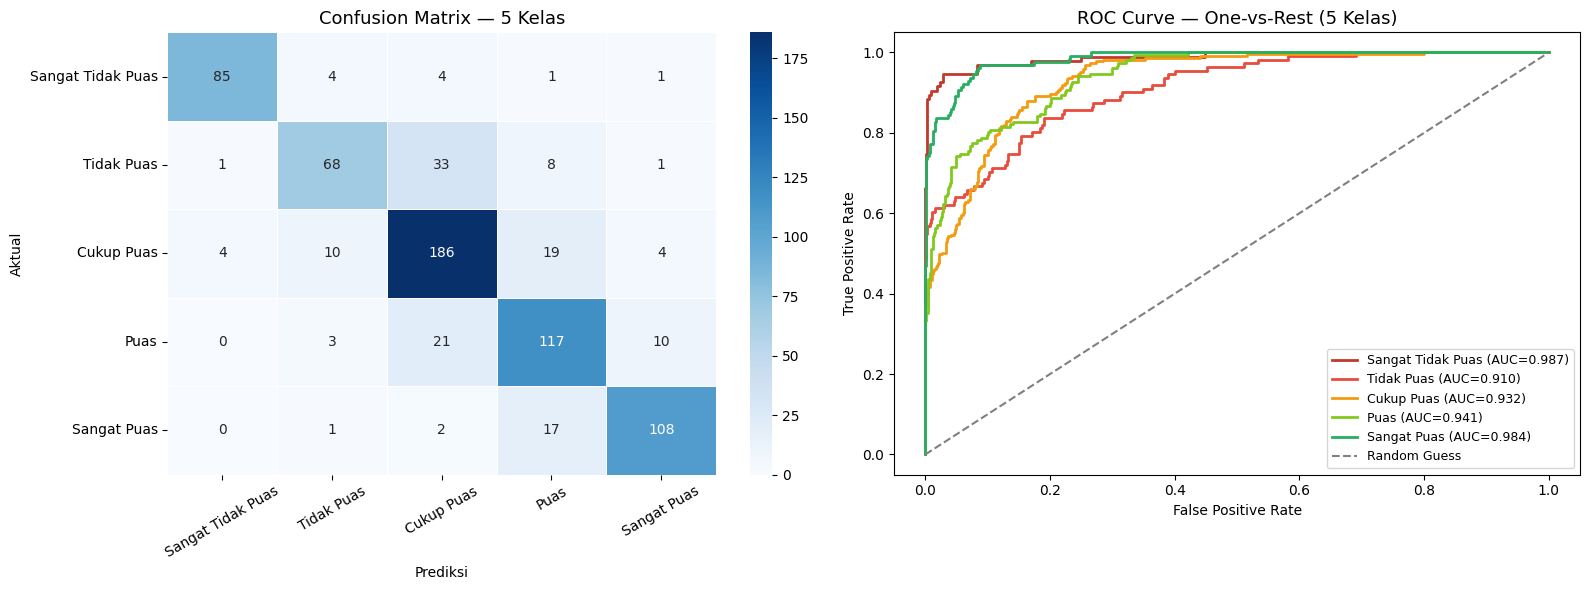

✅ Grafik tersimpan sebagai evaluasi_model.png


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS_TEXT, yticklabels=LABELS_TEXT,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix — 5 Kelas', fontsize=13)
axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# ROC Curve
y_bin         = label_binarize(y, classes=LABELS_ORDER)
auc_per_class = roc_auc_score(y_bin, y_proba, multi_class='ovr', average=None)
auc_macro     = roc_auc_score(y_bin, y_proba, multi_class='ovr', average='macro')
colors        = ['#C0392B', '#E74C3C', '#F39C12', '#82C91E', '#27AE60']

for i, (lbl, color) in enumerate(zip(LABELS_TEXT, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:,i], y_proba[:,i])
    axes[1].plot(fpr, tpr, color=color, lw=2,
                 label=f'{lbl} (AUC={auc_per_class[i]:.3f})')
axes[1].plot([0,1],[0,1],'--', color='gray', label='Random Guess')
axes[1].set_title('ROC Curve — One-vs-Rest (5 Kelas)', fontsize=13)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('evaluasi_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik tersimpan sebagai evaluasi_model.png")


In [34]:
# Classification Report lengkap
report = classification_report(y, y_pred, target_names=LABELS_TEXT, output_dict=True)
print(classification_report(y, y_pred, target_names=LABELS_TEXT))

# Tabel ringkasan untuk Bab IV
ringkasan = pd.DataFrame({
    'Kelas'      : LABELS_TEXT,
    'Precision'  : [report[l]['precision'] for l in LABELS_TEXT],
    'Recall'     : [report[l]['recall']    for l in LABELS_TEXT],
    'F1-Score'   : [report[l]['f1-score']  for l in LABELS_TEXT],
    'AUC (OvR)'  : auc_per_class,
    'Support'    : [int(report[l]['support']) for l in LABELS_TEXT],
})

print(f"Akurasi Keseluruhan : {acc*100:.2f}%")
print(f"AUC Macro Average   : {auc_macro:.3f}")
print(f"Quadratic Weighted Kappa (QWK) : {qwk:.4f}\n")
display(ringkasan.round(4))


                   precision    recall  f1-score   support

Sangat Tidak Puas       0.94      0.89      0.92        95
       Tidak Puas       0.79      0.61      0.69       111
       Cukup Puas       0.76      0.83      0.79       223
             Puas       0.72      0.77      0.75       151
      Sangat Puas       0.87      0.84      0.86       128

         accuracy                           0.80       708
        macro avg       0.82      0.79      0.80       708
     weighted avg       0.80      0.80      0.80       708

Akurasi Keseluruhan : 79.66%
AUC Macro Average   : 0.951
Quadratic Weighted Kappa (QWK) : 0.8835



,Kelas,Precision,Recall,F1-Score,AUC (OvR),Support
0,Sangat Tidak Puas,0.9444,0.8947,0.9189,0.9873,95
1,Tidak Puas,0.7907,0.6126,0.6904,0.9096,111
2,Cukup Puas,0.7561,0.8341,0.7932,0.9325,223
3,Puas,0.7222,0.7748,0.7476,0.9411,151
4,Sangat Puas,0.8710,0.8438,0.8571,0.9836,128


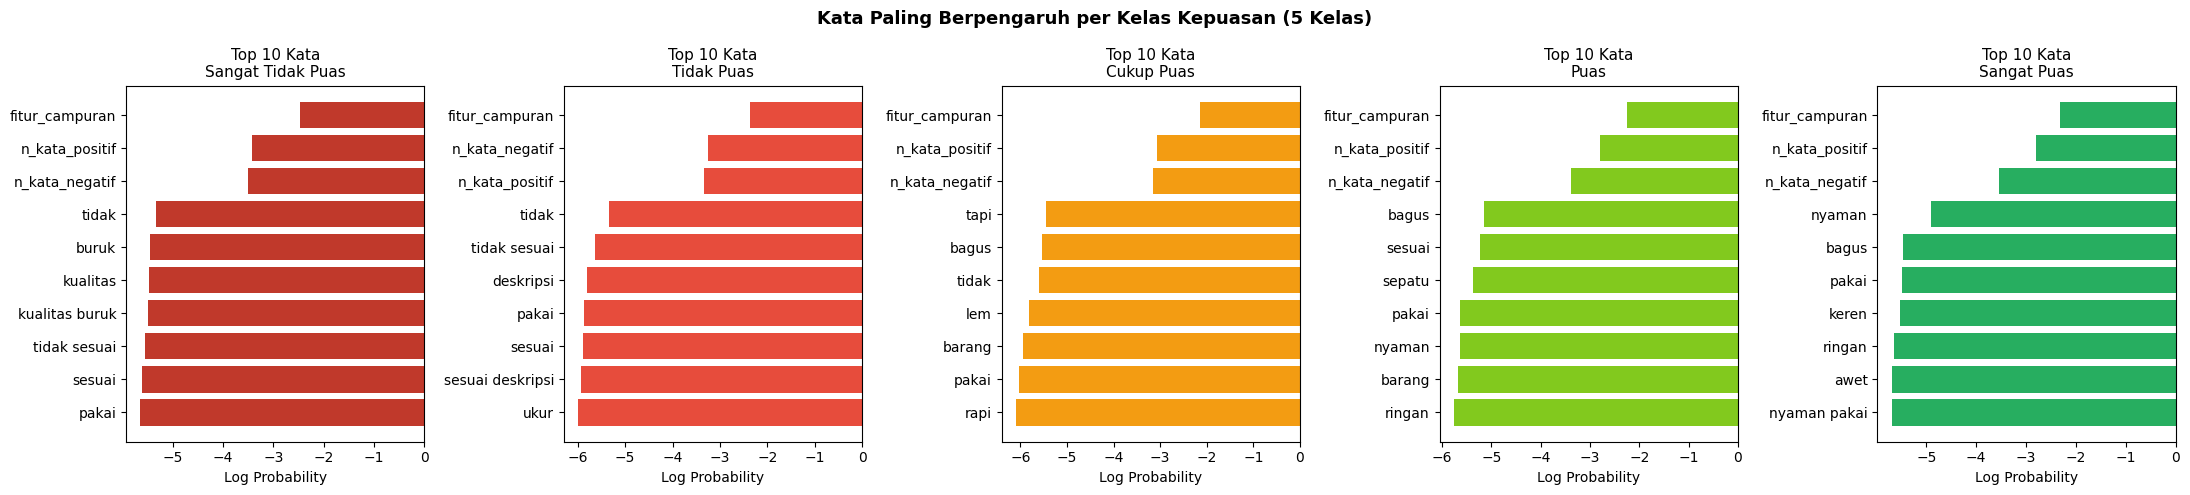

✅ Grafik tersimpan sebagai kata_per_kelas.png


In [35]:
# Visualisasi Top 10 Kata per Kelas
# Catatan: nama fitur sekarang diambil dari ColumnTransformer (prep), gabungan TF-IDF + leksikon,
# lalu disaring pakai selector (Chi-Square) supaya indeksnya tetap cocok dengan model.feature_log_prob_.
fitur_names_semua    = prep.get_feature_names_out()  # contoh: 'tfidf__bagus', 'lex__fitur_campuran'
fitur_names_terpilih = fitur_names_semua[selector.get_support()]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
colors = ['#C0392B', '#E74C3C', '#F39C12', '#82C91E', '#27AE60']

for cls_idx, (cls_name, color) in enumerate(zip(LABELS_TEXT, colors)):
    log_prob  = model.feature_log_prob_[cls_idx]
    top10_idx = log_prob.argsort()[-10:][::-1]
    # buang prefix 'tfidf__'/'lex__' biar enak dibaca di grafik
    top10_kata = [fitur_names_terpilih[i].split('__', 1)[-1] for i in top10_idx]
    top10_skor = [log_prob[i] for i in top10_idx]

    axes[cls_idx].barh(top10_kata[::-1], top10_skor[::-1], color=color)
    axes[cls_idx].set_title(f'Top 10 Kata\n{cls_name}', fontsize=11)
    axes[cls_idx].set_xlabel('Log Probability')

plt.suptitle('Kata Paling Berpengaruh per Kelas Kepuasan (5 Kelas)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kata_per_kelas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik tersimpan sebagai kata_per_kelas.png")


## Sel 6 — Simpan Model ke File (untuk Dashboard Streamlit Cloud)

Model dan TF-IDF vectorizer disimpan ke file `.pkl` agar dashboard
Streamlit Cloud bisa langsung memuatnya **tanpa perlu melatih ulang**
setiap kali halaman dibuka.


In [36]:
# Simpan SATU pipeline lengkap (TF-IDF + leksikon + Chi-Square + Naive Bayes).
# Ini menyederhanakan deployment: dashboard Streamlit tinggal panggil pipeline_final.predict(df_baru)
# tanpa perlu menyimpan/menyusun ulang tfidf, selector, dan model secara terpisah.
joblib.dump(pipeline_final, 'pipeline_geoffmax.pkl')

print("✅ Pipeline berhasil disimpan!")
print("   pipeline_geoffmax.pkl  — Pipeline lengkap (TF-IDF + leksikon + Chi-Square + Naive Bayes)")
print()
print("Cara pakai di app Streamlit:")
print("  pipeline = joblib.load('pipeline_geoffmax.pkl')")
print("  # df_baru harus punya kolom: ulasan_bersih, n_kata_positif, n_kata_negatif, fitur_campuran")
print("  pred = pipeline.predict(df_baru)")
print()
print("Langkah selanjutnya:")
print("1. Download file .pkl ini ke komputer Anda")
print("2. Upload ke GitHub bersama app_geoffmax.py dan requirements.txt")
print("3. Deploy ke share.streamlit.io")

# Auto-download
from google.colab import files
files.download('pipeline_geoffmax.pkl')


✅ Pipeline berhasil disimpan!
   pipeline_geoffmax.pkl  — Pipeline lengkap (TF-IDF + leksikon + Chi-Square + Naive Bayes)

Cara pakai di app Streamlit:
  pipeline = joblib.load('pipeline_geoffmax.pkl')
  # df_baru harus punya kolom: ulasan_bersih, n_kata_positif, n_kata_negatif, fitur_campuran
  pred = pipeline.predict(df_baru)

Langkah selanjutnya:
1. Download file .pkl ini ke komputer Anda
2. Upload ke GitHub bersama app_geoffmax.py dan requirements.txt
3. Deploy ke share.streamlit.io


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Sel 7 — Demo Prediksi Ulasan Baru

Uji coba model dengan memasukkan ulasan baru secara manual.


In [37]:
def prediksi_ulasan(teks_baru):
    teks_bersih = preprocess(teks_baru)
    n_pos, n_neg, campuran = hitung_fitur_leksikon(teks_bersih)

    # Bentuk baris input sesuai kolom yang dipakai saat training (lihat X_df di Sel 3c)
    df_input = pd.DataFrame([{
        'ulasan_bersih': teks_bersih,
        'n_kata_positif': n_pos,
        'n_kata_negatif': n_neg,
        'fitur_campuran': campuran
    }])

    pred_kelas = pipeline_final.predict(df_input)[0]
    pred_proba = pipeline_final.predict_proba(df_input)[0]

    emoji = {0:'😡', 1:'😞', 2:'😐', 3:'🙂', 4:'😍'}
    print(f"Ulasan   : {teks_baru}")
    print(f"Bersih   : {teks_bersih}")
    print(f"Prediksi : {emoji[pred_kelas]} {LABEL_MAP[pred_kelas]}")
    print("Probabilitas:")
    for lbl, prob in zip(LABELS_TEXT, pred_proba):
        bar = '█' * int(prob * 30)
        print(f"  {lbl:18s}: {bar} {prob*100:.1f}%")
    print()

# Uji dengan beberapa contoh ulasan
prediksi_ulasan("sepatunya bagus banget kualitas oke nyaman dipakai seharian")
prediksi_ulasan("kecewa banget kualitas buruk sol lepas setelah 3 hari dipakai")
prediksi_ulasan("lumayan sih untuk harga segini tidak jelek tidak bagus juga")
prediksi_ulasan("sepatu oke tapi agak kurang nyaman di jari kaki, lumayan lah")


Ulasan   : sepatunya bagus banget kualitas oke nyaman dipakai seharian
Bersih   : sepatu bagus banget kualitas oke nyaman pakai hari
Prediksi : 🙂 Puas
Probabilitas:
  Sangat Tidak Puas :  0.7%
  Tidak Puas        :  1.8%
  Cukup Puas        : █████ 17.2%
  Puas              : ███████████████ 52.1%
  Sangat Puas       : ████████ 28.2%

Ulasan   : kecewa banget kualitas buruk sol lepas setelah 3 hari dipakai
Bersih   : kecewa banget kualitas buruk sol lepas pakai
Prediksi : 😞 Tidak Puas
Probabilitas:
  Sangat Tidak Puas : ███████ 25.3%
  Tidak Puas        : ███████████ 39.2%
  Cukup Puas        : █████████ 32.7%
  Puas              :  1.6%
  Sangat Puas       :  1.2%

Ulasan   : lumayan sih untuk harga segini tidak jelek tidak bagus juga
Bersih   : lumayan harga gin tidak jelek tidak bagus
Prediksi : 😐 Cukup Puas
Probabilitas:
  Sangat Tidak Puas : █ 3.8%
  Tidak Puas        : ███████ 26.2%
  Cukup Puas        : ██████████████ 49.5%
  Puas              : █████ 17.5%
  Sangat Puas       :